In [1]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import os
import time

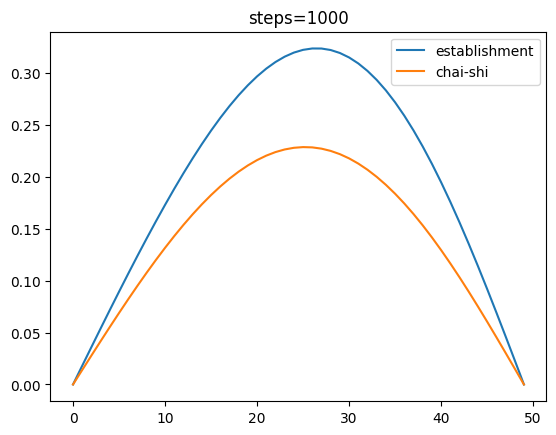

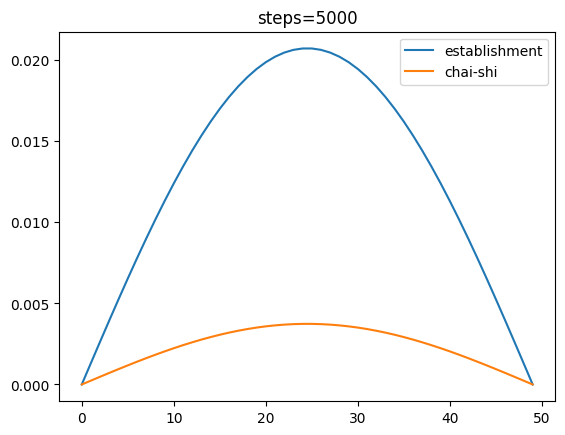

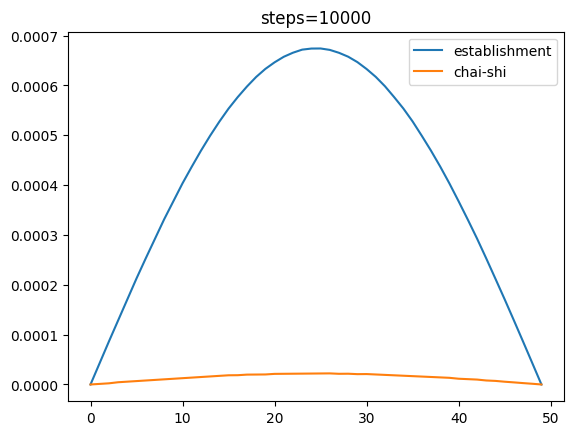

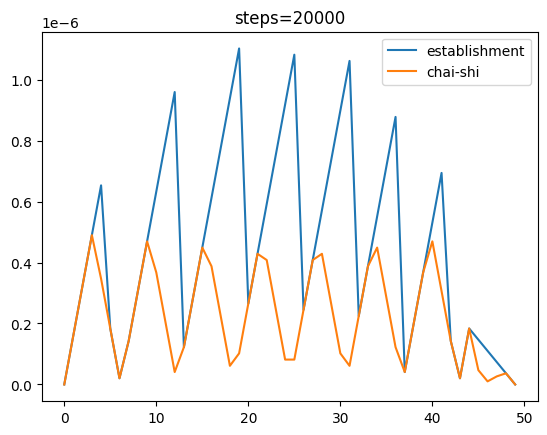

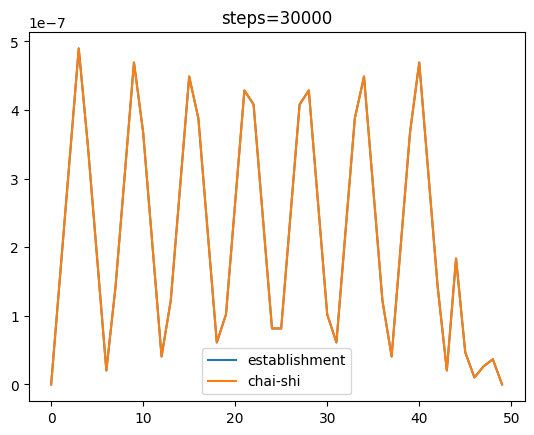

In [5]:
# chai-shi vs establishment

subprocess.run(["g++", "chai_shi.cpp", "-Ofast", "-o", "chai_shi.exe"])
subprocess.run(["g++", "establishment.cpp", "-Ofast", "-o", "establishment.exe"])

steps_arr = [1000, 5000, 10000, 20000, 30000]

for steps in steps_arr:
    subprocess.run(["chai_shi.exe", "50", "30", "1.0", f"{steps}"])
    subprocess.run(["establishment.exe", "50", "30", "1.0", f"{steps}"])
    
    data_chai_shi = np.loadtxt("result_chai_shi.csv")
    data_est = np.loadtxt("result_est.csv")
    
    grid = np.arange(len(data_est[0, :]))
    x_est = data_est[10, :]
    x_chai_shi = data_chai_shi[10, :]
    
    x_an = 1 - grid/(len(x_est)-1)
    plt.figure()
    plt.plot(np.abs(x_est - x_an), label=f"establishment")
    plt.plot(np.abs(x_chai_shi - x_an), label=f"chai-shi")
    plt.title(f"steps={steps}")
    plt.legend()



os.remove("result_est.csv")
os.remove("result_chai_shi.csv")
os.remove("establishment.exe")
os.remove("chai_shi.exe")